In [2]:
import seaborn as sns
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix,accuracy_score,classification_report
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier,GradientBoostingClassifier,AdaBoostClassifier


import warnings
warnings.filterwarnings("ignore")


In [3]:
kidney_dataset=pd.read_csv("kidney_disease.csv")
kidney_dataset

,id,age,bp,sg,al,su,rbc,pc,pcc,ba,...,pcv,wc,rc,htn,dm,cad,appet,pe,ane,classification
0,0,48.0,80.0,1.020,1.0,0.0,NaN,normal,notpresent,notpresent,...,44,7800,5.2,yes,yes,no,good,no,no,ckd
1,1,7.0,50.0,1.020,4.0,0.0,NaN,normal,notpresent,notpresent,...,38,6000,NaN,no,no,no,good,no,no,ckd
2,2,62.0,80.0,1.010,2.0,3.0,normal,normal,notpresent,notpresent,...,31,7500,NaN,no,yes,no,poor,no,yes,ckd
3,3,48.0,70.0,1.005,4.0,0.0,normal,abnormal,present,notpresent,...,32,6700,3.9,yes,no,no,poor,yes,yes,ckd
4,4,51.0,80.0,1.010,2.0,0.0,normal,normal,notpresent,notpresent,...,35,7300,4.6,no,no,no,good,no,no,ckd
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
395,395,55.0,80.0,1.020,0.0,0.0,normal,normal,notpresent,notpresent,...,47,6700,4.9,no,no,no,good,no,no,notckd
396,396,42.0,70.0,1.025,0.0,0.0,normal,normal,notpresent,notpresent,...,54,7800,6.2,no,no,no,good,no,no,notckd
397,397,12.0,80.0,1.020,0.0,0.0,normal,normal,notpresent,notpresent,...,49,6600,5.4,no,no,no,good,no,no,notckd
398,398,17.0,60.0,1.025,0.0,0.0,normal,normal,notpresent,notpresent,...,51,7200,5.9,no,no,no,good,no,no,notckd


In [4]:
kidney_dataset.shape

(400, 26)

In [5]:
kidney_dataset.describe()

,id,age,bp,sg,al,su,bgr,bu,sc,sod,pot,hemo
count,400.000000,391.000000,388.000000,353.000000,354.000000,351.000000,356.000000,381.000000,383.000000,313.000000,312.000000,348.000000
mean,199.500000,51.483376,76.469072,1.017408,1.016949,0.450142,148.036517,57.425722,3.072454,137.528754,4.627244,12.526437
std,115.614301,17.169714,13.683637,0.005717,1.352679,1.099191,79.281714,50.503006,5.741126,10.408752,3.193904,2.912587
min,0.000000,2.000000,50.000000,1.005000,0.000000,0.000000,22.000000,1.500000,0.400000,4.500000,2.500000,3.100000
25%,99.750000,42.000000,70.000000,1.010000,0.000000,0.000000,99.000000,27.000000,0.900000,135.000000,3.800000,10.300000
50%,199.500000,55.000000,80.000000,1.020000,0.000000,0.000000,121.000000,42.000000,1.300000,138.000000,4.400000,12.650000
75%,299.250000,64.500000,80.000000,1.020000,2.000000,0.000000,163.000000,66.000000,2.800000,142.000000,4.900000,15.000000
max,399.000000,90.000000,180.000000,1.025000,5.000000,5.000000,490.000000,391.000000,76.000000,163.000000,47.000000,17.800000


In [6]:
kidney_dataset.dtypes

id                  int64
age               float64
bp                float64
sg                float64
al                float64
su                float64
rbc                object
pc                 object
pcc                object
ba                 object
bgr               float64
bu                float64
sc                float64
sod               float64
pot               float64
hemo              float64
pcv                object
wc                 object
rc                 object
htn                object
dm                 object
cad                object
appet              object
pe                 object
ane                object
classification     object
dtype: object

In [7]:
kidney_dataset.isna().sum()

id                  0
age                 9
bp                 12
sg                 47
al                 46
su                 49
rbc               152
pc                 65
pcc                 4
ba                  4
bgr                44
bu                 19
sc                 17
sod                87
pot                88
hemo               52
pcv                70
wc                105
rc                130
htn                 2
dm                  2
cad                 2
appet               1
pe                  1
ane                 1
classification      0
dtype: int64

In [8]:
kidney_dataset["age"].unique

<bound method Series.unique of 0      48.0
1       7.0
2      62.0
3      48.0
4      51.0
       ... 
395    55.0
396    42.0
397    12.0
398    17.0
399    58.0
Name: age, Length: 400, dtype: float64>

In [9]:
kidney_dataset.isna().any()

id                False
age                True
bp                 True
sg                 True
al                 True
su                 True
rbc                True
pc                 True
pcc                True
ba                 True
bgr                True
bu                 True
sc                 True
sod                True
pot                True
hemo               True
pcv                True
wc                 True
rc                 True
htn                True
dm                 True
cad                True
appet              True
pe                 True
ane                True
classification    False
dtype: bool

In [10]:
col_analysis=[]

for col in kidney_dataset.columns:
    col_analysis.append({
        "col_name":col,
        "datatype":kidney_dataset[col].dtypes,
        "data_value":kidney_dataset[col].nunique(),
        "unique_values":kidney_dataset[col].unique()[:5],
        "null_values":kidney_dataset[col].isnull().sum()
    })

df1=pd.DataFrame(col_analysis)
df1

,col_name,datatype,data_value,unique_values,null_values
0,id,int64,400,"[0, 1, 2, 3, 4]",0
1,age,float64,76,"[48.0, 7.0, 62.0, 51.0, 60.0]",9
2,bp,float64,10,"[80.0, 50.0, 70.0, 90.0, nan]",12
3,sg,float64,5,"[1.02, 1.01, 1.005, 1.015, nan]",47
4,al,float64,6,"[1.0, 4.0, 2.0, 3.0, 0.0]",46
5,su,float64,6,"[0.0, 3.0, 4.0, 1.0, nan]",49
6,rbc,object,2,"[nan, normal, abnormal]",152
7,pc,object,2,"[normal, abnormal, nan]",65
8,pcc,object,2,"[notpresent, present, nan]",4
9,ba,object,2,"[notpresent, present, nan]",4


In [11]:
kidney_dataset['classification']=kidney_dataset['classification'].str.strip()
kidney_dataset = kidney_dataset.iloc[:, 1:]
cols=['htn','appet','pe','ane']
for col in cols:
    kidney_dataset[col]=kidney_dataset[col].fillna(kidney_dataset[col].mode())


for col in kidney_dataset.columns:
    if kidney_dataset[col].dtype == 'object':
        kidney_dataset[col].fillna(kidney_dataset[col].mode()[0], inplace=True)
    else:
        kidney_dataset[col].fillna(kidney_dataset[col].median(), inplace=True)



kidney_dataset['cad']=kidney_dataset['cad'].replace({"\tno":'yes'})
kidney_dataset['dm']=kidney_dataset['dm'].replace({"\tno":'no'})
kidney_dataset['dm']=kidney_dataset['dm'].replace({"\tyes":'yes'})
kidney_dataset['dm']=kidney_dataset['dm'].replace({"yes":"Yes"})
kidney_dataset['dm']=kidney_dataset['dm'].replace({"no":"No"})
kidney_dataset['dm']=kidney_dataset['dm'].replace({"yes":"Yes"})

kidney_dataset['dm'] = kidney_dataset['dm'].str.lower().str.strip()
kidney_dataset['dm']=kidney_dataset['dm'].replace({"yes":"Yes"})

import numpy as np

kidney_dataset.replace('?', np.nan, inplace=True)
kidney_dataset.replace('\t?', np.nan, inplace=True)


for col in kidney_dataset.select_dtypes(include="object").columns:
    kidney_dataset[col]=kidney_dataset[col].fillna(kidney_dataset[col].mode()[0])



kidney_dataset['pcv']=kidney_dataset['pcv'].astype(int)
kidney_dataset['wc']=kidney_dataset['wc'].astype(int)
kidney_dataset['rc']=kidney_dataset['rc'].astype(float)


binary_map={
    'ckd':1,'notckd':0,
    'normal':0,'abnormal':1,
    'present':1,'notpresent':0,
    'good':0,'poor':1,
    'yes':1,'no':0
}


for col in kidney_dataset.select_dtypes(include='object').columns:
    kidney_dataset[col]=kidney_dataset[col].str.lower().str.strip()
    kidney_dataset[col]=kidney_dataset[col].map(binary_map)





In [42]:
rows_con=['bp','age','sod','bgr','su','bu']
kidney_dataset[rows_con]=kidney_dataset[rows_con].astype(int)

In [23]:
kidney_dataset

,age,bp,sg,al,su,rbc,pc,pcc,ba,bgr,...,pcv,wc,rc,htn,dm,cad,appet,pe,ane,classification
0,48,80,1.020,1.0,0,0,0,0,0,121,...,44,7800,5.2,1,1,0,0,0,0,1
1,7,50,1.020,4.0,0,0,0,0,0,121,...,38,6000,5.2,0,0,0,0,0,0,1
2,62,80,1.010,2.0,3,0,0,0,0,423,...,31,7500,5.2,0,1,0,1,0,1,1
3,48,70,1.005,4.0,0,0,1,1,0,117,...,32,6700,3.9,1,0,0,1,1,1,1
4,51,80,1.010,2.0,0,0,0,0,0,106,...,35,7300,4.6,0,0,0,0,0,0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
395,55,80,1.020,0.0,0,0,0,0,0,140,...,47,6700,4.9,0,0,0,0,0,0,0
396,42,70,1.025,0.0,0,0,0,0,0,75,...,54,7800,6.2,0,0,0,0,0,0,0
397,12,80,1.020,0.0,0,0,0,0,0,100,...,49,6600,5.4,0,0,0,0,0,0,0
398,17,60,1.025,0.0,0,0,0,0,0,114,...,51,7200,5.9,0,0,0,0,0,0,0


In [13]:
kidney_dataset.dtypes

age                 int64
bp                  int64
sg                float64
al                float64
su                float64
rbc                 int64
pc                  int64
pcc                 int64
ba                  int64
bgr                 int64
bu                float64
sc                float64
sod                 int64
pot               float64
hemo              float64
pcv                 int64
wc                  int64
rc                float64
htn                 int64
dm                  int64
cad                 int64
appet               int64
pe                  int64
ane                 int64
classification      int64
dtype: object

In [14]:
kidney_dataset.columns

Index(['age', 'bp', 'sg', 'al', 'su', 'rbc', 'pc', 'pcc', 'ba', 'bgr', 'bu',
       'sc', 'sod', 'pot', 'hemo', 'pcv', 'wc', 'rc', 'htn', 'dm', 'cad',
       'appet', 'pe', 'ane', 'classification'],
      dtype='object')

In [15]:
kidney_dataset.isna().sum()

age               0
bp                0
sg                0
al                0
su                0
rbc               0
pc                0
pcc               0
ba                0
bgr               0
bu                0
sc                0
sod               0
pot               0
hemo              0
pcv               0
wc                0
rc                0
htn               0
dm                0
cad               0
appet             0
pe                0
ane               0
classification    0
dtype: int64

<Axes: xlabel='age', ylabel='Count'>

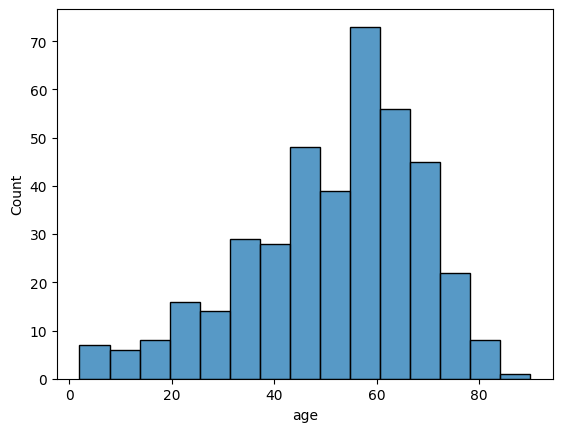

In [85]:
sns.histplot(data=kidney_dataset,x='age')

<Axes: xlabel='classification', ylabel='count'>

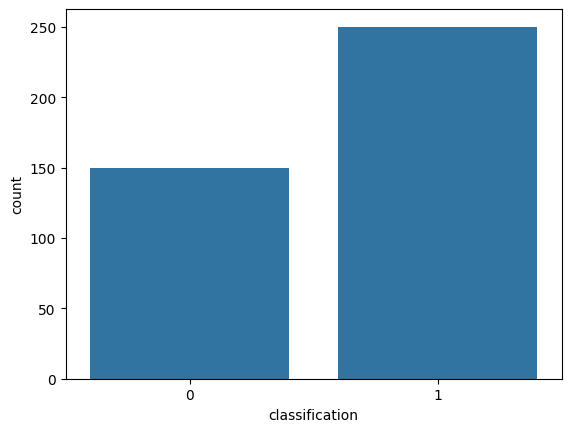

In [16]:
sns.countplot(kidney_dataset,x='classification')

In [35]:
corr=kidney_dataset[['sc','pot','dm','cad','bu','sod','pe','appet']].corr()
print(corr)

             sc       pot        dm       cad        bu       sod        pe  \
sc     1.000000  0.204751  0.209763  0.186938  0.581517 -0.624571  0.176685   
pot    0.204751  1.000000  0.057615  0.006259  0.339771  0.069484  0.061354   
dm     0.209763  0.057615  1.000000  0.251645  0.315958 -0.264361  0.308463   
cad    0.186938  0.006259  0.251645  1.000000  0.220573 -0.214938  0.159438   
bu     0.581517  0.339771  0.315958  0.220573  1.000000 -0.308538  0.338740   
sod   -0.624571  0.069484 -0.264361 -0.214938 -0.308538  1.000000 -0.150018   
pe     0.176685  0.061354  0.308463  0.159438  0.338740 -0.150018  1.000000   
appet  0.162131 -0.019855  0.325134  0.143250  0.274123 -0.157732  0.417055   

          appet  
sc     0.162131  
pot   -0.019855  
dm     0.325134  
cad    0.143250  
bu     0.274123  
sod   -0.157732  
pe     0.417055  
appet  1.000000  


<Axes: >

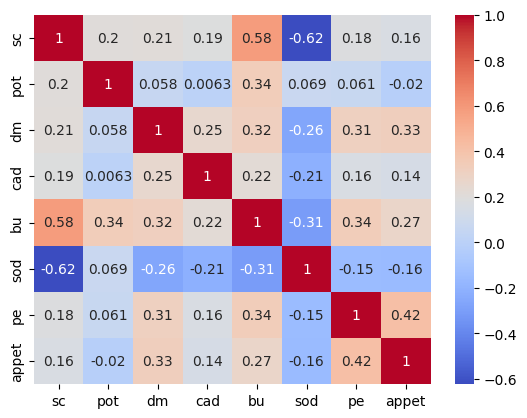

In [36]:
sns.heatmap(corr,annot=True,cmap="coolwarm")

<Axes: xlabel='bgr'>

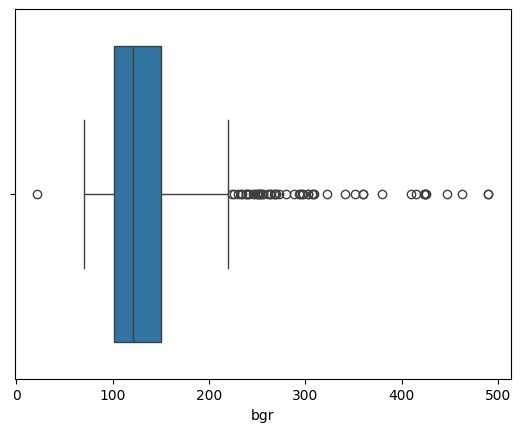

In [20]:
sns.boxplot(data=kidney_dataset,x='bgr')

In [24]:
kidney_dataset

,age,bp,sg,al,su,rbc,pc,pcc,ba,bgr,...,pcv,wc,rc,htn,dm,cad,appet,pe,ane,classification
0,48,80,1.020,1.0,0,0,0,0,0,121,...,44,7800,5.2,1,1,0,0,0,0,1
1,7,50,1.020,4.0,0,0,0,0,0,121,...,38,6000,5.2,0,0,0,0,0,0,1
2,62,80,1.010,2.0,3,0,0,0,0,423,...,31,7500,5.2,0,1,0,1,0,1,1
3,48,70,1.005,4.0,0,0,1,1,0,117,...,32,6700,3.9,1,0,0,1,1,1,1
4,51,80,1.010,2.0,0,0,0,0,0,106,...,35,7300,4.6,0,0,0,0,0,0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
395,55,80,1.020,0.0,0,0,0,0,0,140,...,47,6700,4.9,0,0,0,0,0,0,0
396,42,70,1.025,0.0,0,0,0,0,0,75,...,54,7800,6.2,0,0,0,0,0,0,0
397,12,80,1.020,0.0,0,0,0,0,0,100,...,49,6600,5.4,0,0,0,0,0,0,0
398,17,60,1.025,0.0,0,0,0,0,0,114,...,51,7200,5.9,0,0,0,0,0,0,0


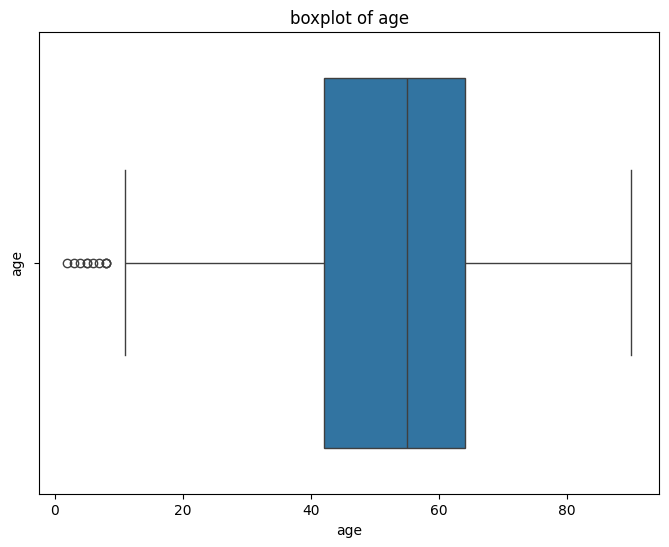

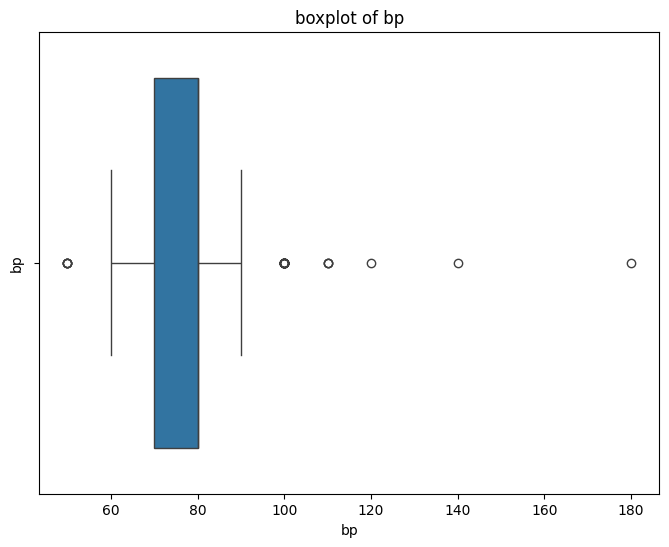

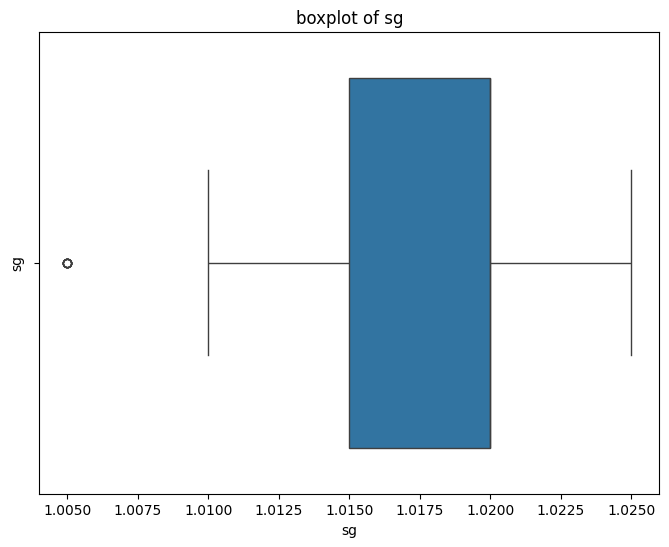

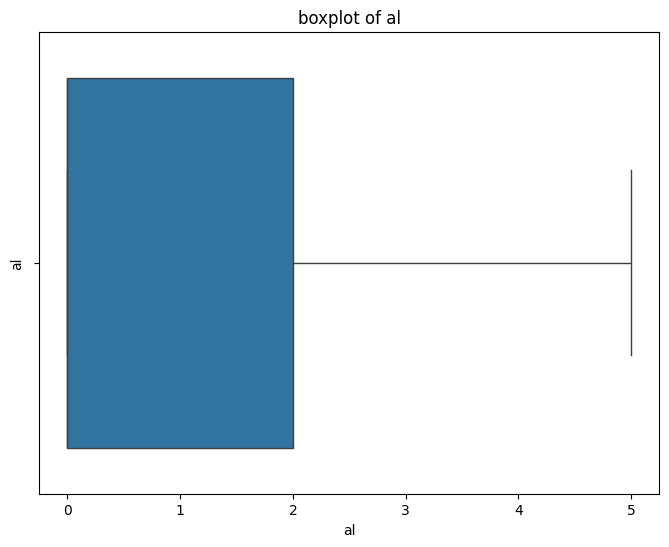

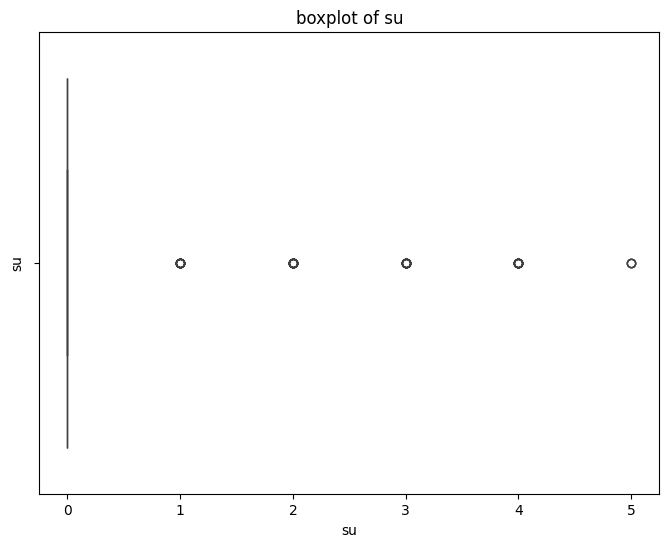

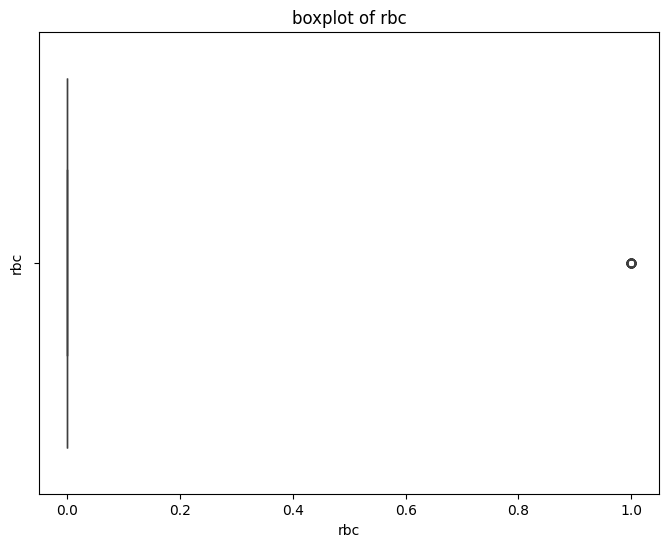

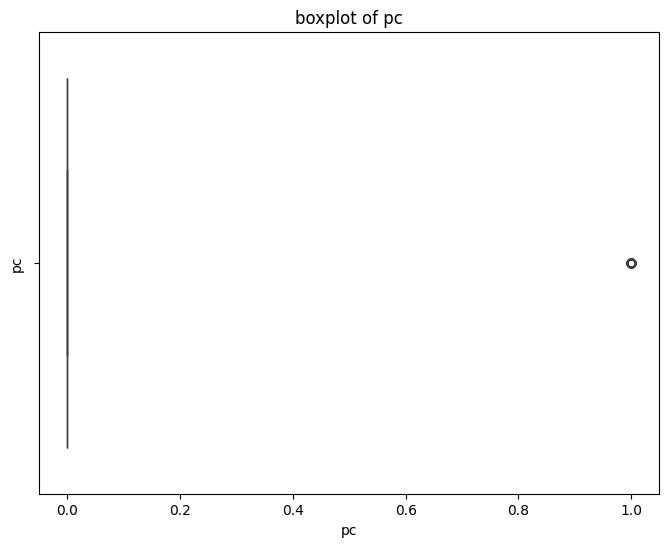

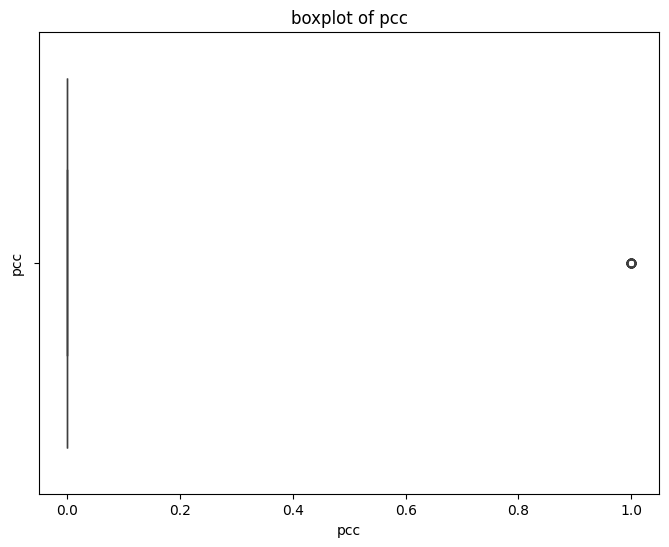

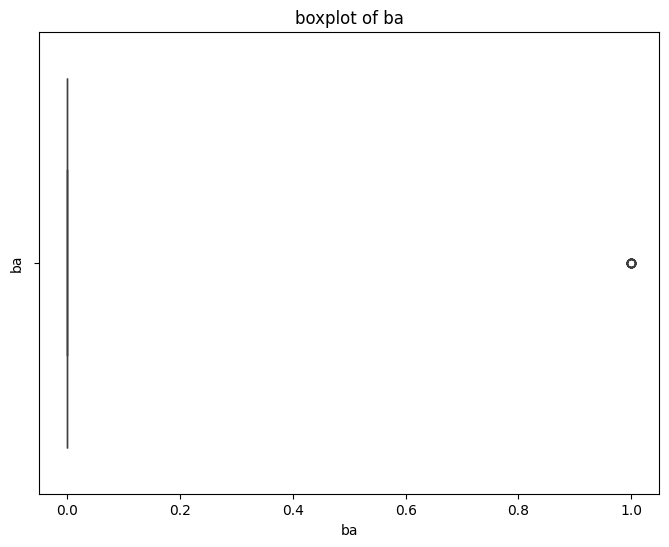

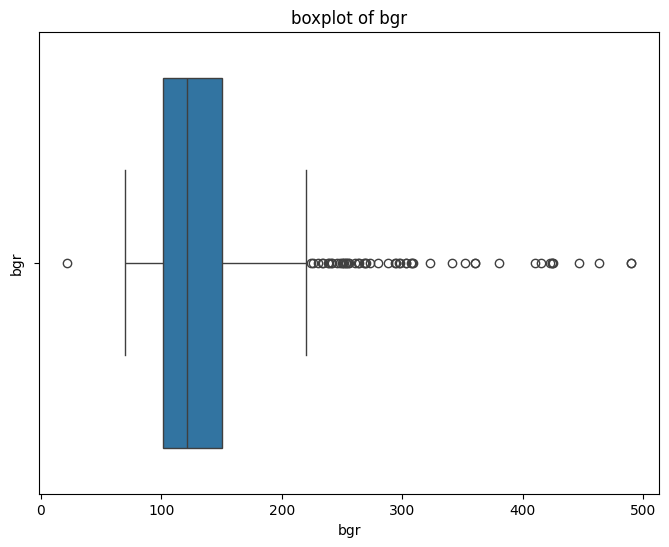

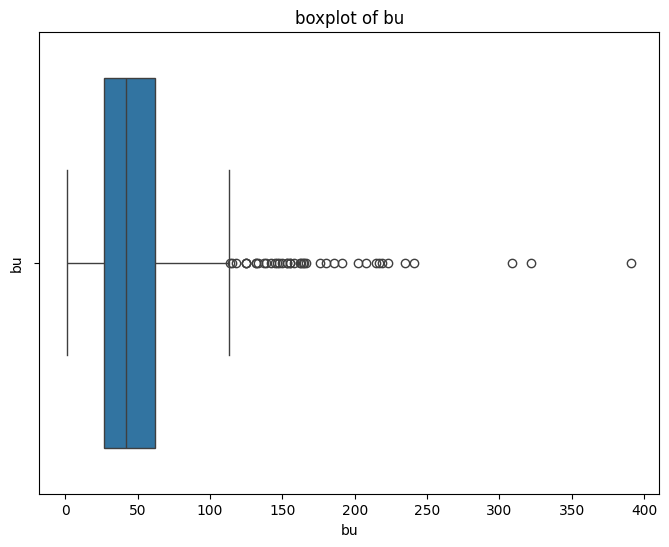

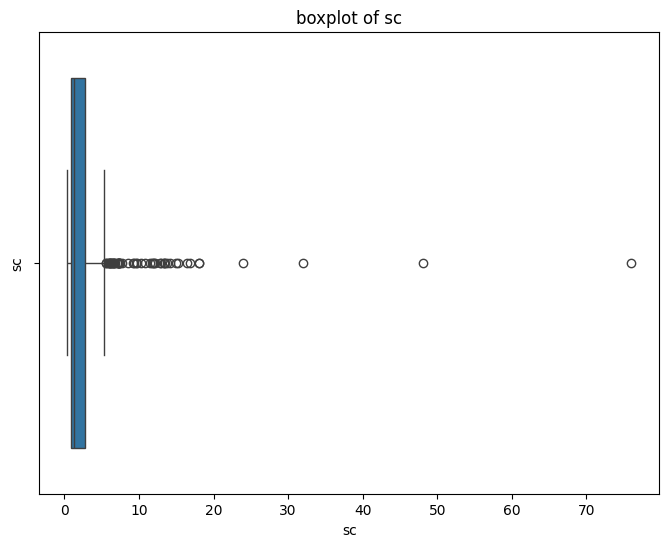

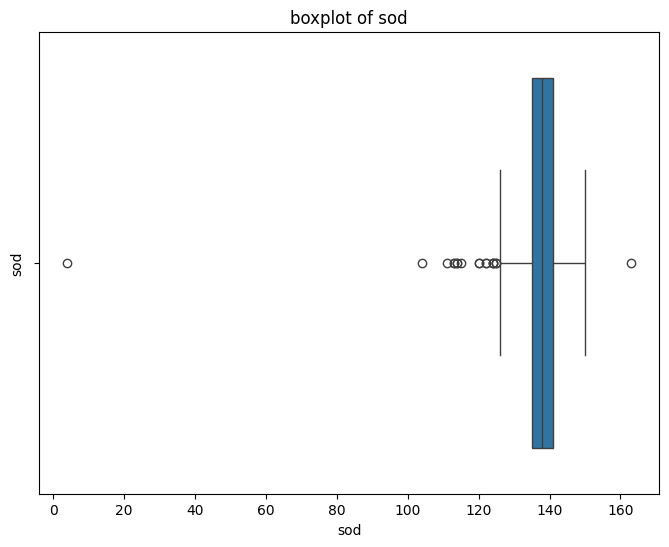

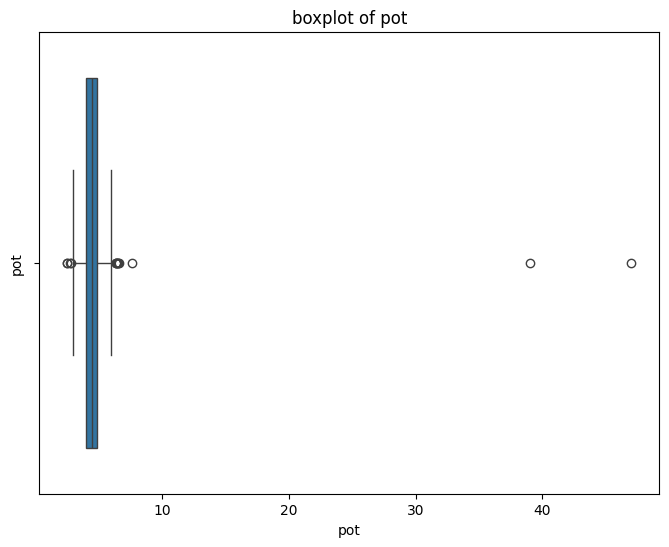

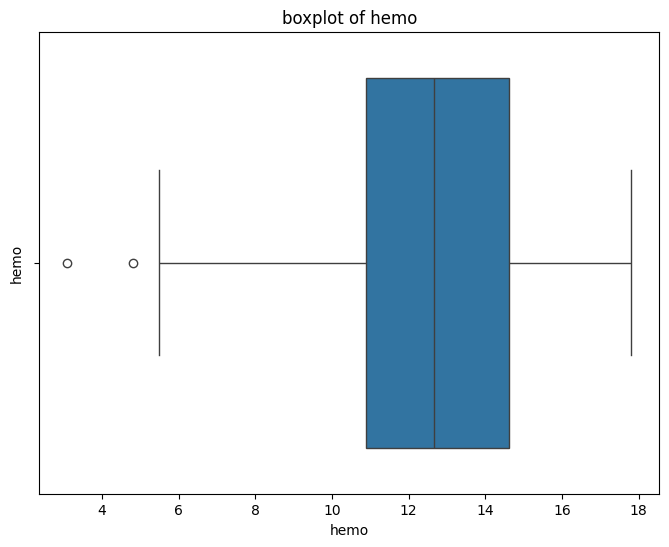

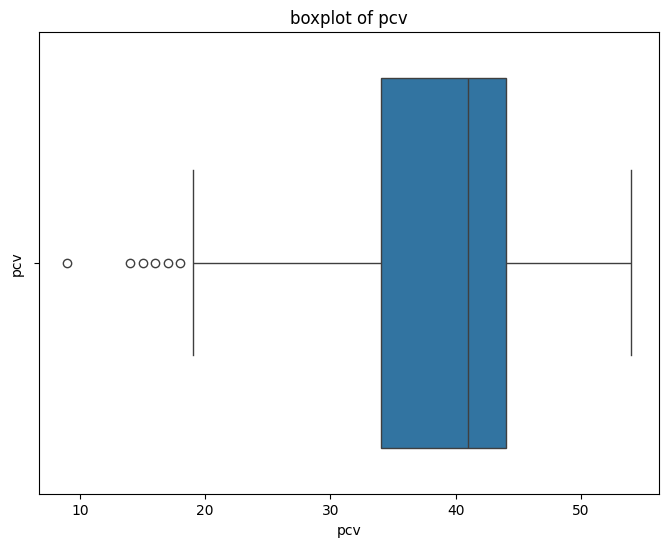

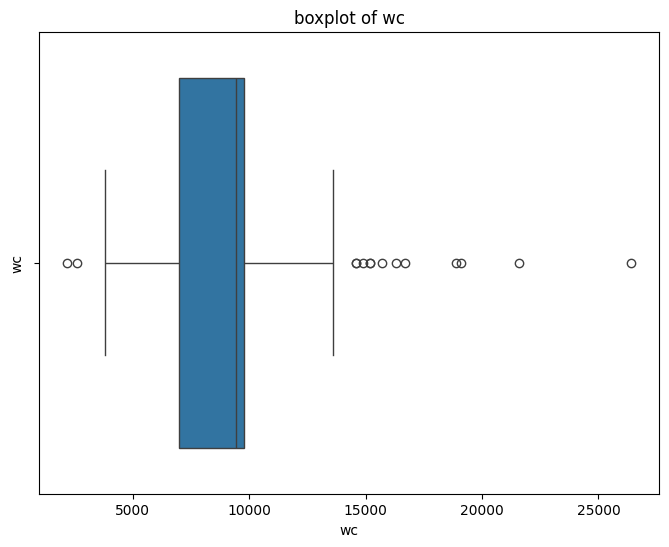

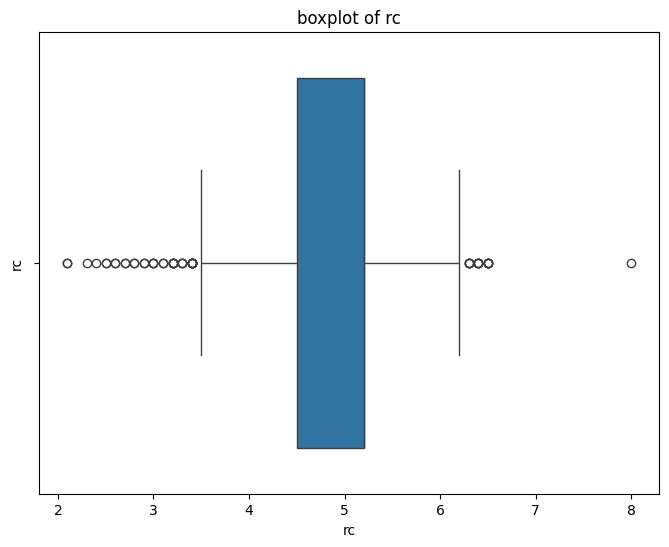

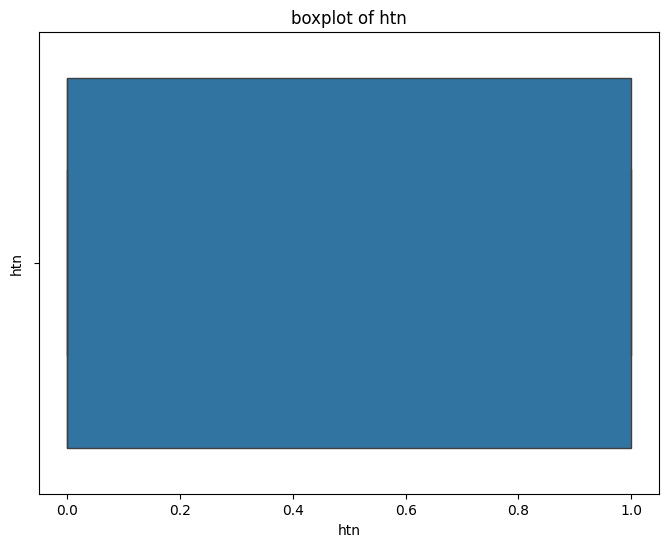

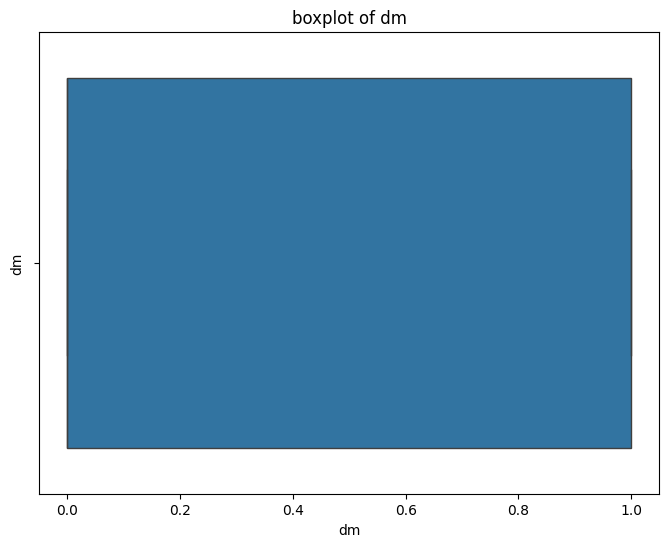

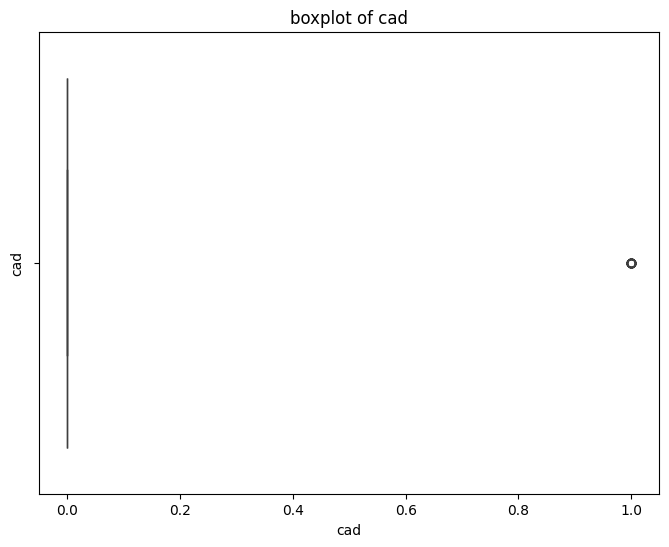

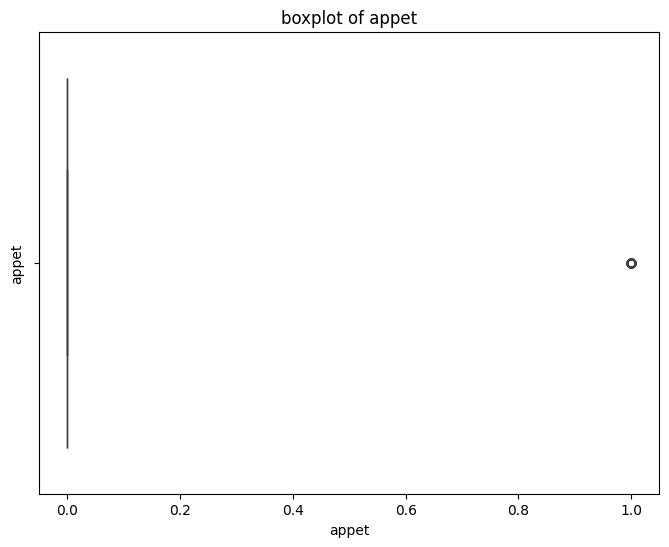

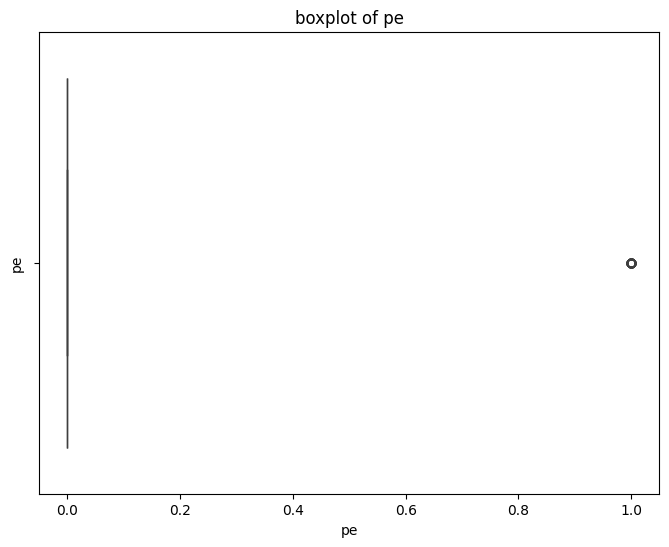

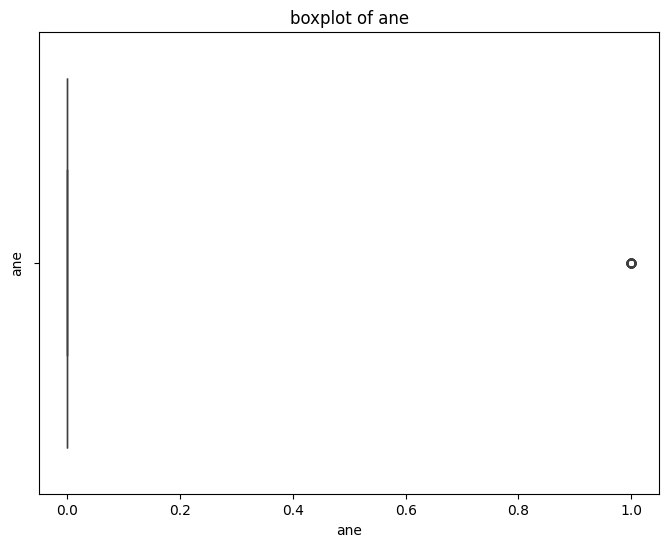

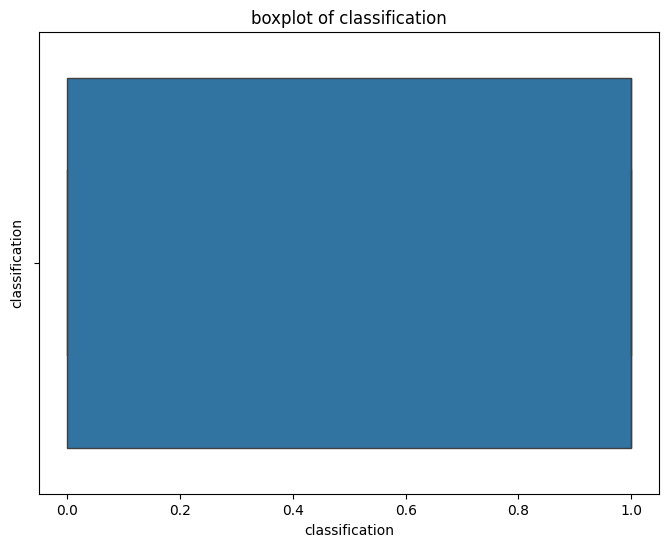

In [32]:
num_col=kidney_dataset.select_dtypes(include=np.number).columns
for col in num_col:
    plt.figure(figsize=(8,6))
    sns.boxplot(x=kidney_dataset[col])
    plt.tight_layout
    plt.title(f'boxplot of {col}',fontsize=12)
    plt.ylabel(col)
    plt.show()

In [43]:
x=kidney_dataset[['sc','pot','dm','cad','bu','sod','pe','appet']]
y=kidney_dataset['classification']

In [ ]:
sns.lmplot

In [44]:
x

,sc,pot,dm,cad,bu,sod,pe,appet
0,1.2,4.4,1,0,36,138,0,0
1,0.8,4.4,0,0,18,138,0,0
2,1.8,4.4,1,0,53,138,0,1
3,3.8,2.5,0,0,56,111,1,1
4,1.4,4.4,0,0,26,138,0,0
...,...,...,...,...,...,...,...,...
395,0.5,4.9,0,0,49,150,0,0
396,1.2,3.5,0,0,31,141,0,0
397,0.6,4.4,0,0,26,137,0,0
398,1.0,4.9,0,0,50,135,0,0


In [45]:
y

0      1
1      1
2      1
3      1
4      1
      ..
395    0
396    0
397    0
398    0
399    0
Name: classification, Length: 400, dtype: int64

In [46]:
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.3,random_state=42,shuffle=True,stratify=y)

In [47]:
x_train.shape,y_train.shape

((280, 8), (280,))

In [48]:
x_test.shape,y_test.shape

((120, 8), (120,))

In [49]:
x_train

,sc,pot,dm,cad,bu,sod,pe,appet
364,0.7,3.5,0,0,44,137,0,0
135,1.3,4.0,1,0,24,140,0,1
322,0.5,4.6,0,0,40,140,0,0
234,1.3,4.4,0,0,19,138,0,0
388,1.2,3.7,0,0,15,144,0,0
...,...,...,...,...,...,...,...,...
203,6.8,5.5,1,0,80,142,0,0
30,7.3,4.9,1,0,155,132,0,0
346,0.9,4.4,0,0,41,141,0,0
137,4.0,5.1,1,0,86,134,0,0


In [50]:
y_train

364    0
135    1
322    0
234    1
388    0
      ..
203    1
30     1
346    0
137    1
370    0
Name: classification, Length: 280, dtype: int64

In [52]:
logistic_model=LogisticRegression(max_iter=200)
logistic_model.fit(x_train,y_train)
y_pred=logistic_model.predict(x_test)
y_pred

array([1, 0, 1, 0, 1, 1, 1, 0, 0, 0, 1, 1, 0, 1, 0, 1, 1, 0, 1, 1, 0, 0,
       1, 0, 1, 1, 1, 0, 1, 0, 1, 0, 1, 1, 1, 1, 1, 0, 0, 0, 0, 0, 0, 1,
       0, 0, 1, 1, 0, 1, 1, 1, 1, 0, 0, 1, 0, 0, 1, 0, 1, 1, 1, 1, 1, 0,
       0, 1, 1, 1, 1, 1, 0, 0, 1, 0, 1, 1, 0, 0, 0, 0, 0, 0, 1, 0, 1, 0,
       0, 1, 0, 0, 1, 1, 0, 0, 1, 0, 1, 0, 0, 1, 0, 1, 1, 1, 1, 1, 1, 1,
       1, 0, 1, 0, 0, 0, 1, 1, 1, 0])

In [53]:
y_train_pred = logistic_model.predict(x_train)
y_test_pred  = logistic_model.predict(x_test)

train_acc = accuracy_score(y_train, y_train_pred)
test_acc  = accuracy_score(y_test, y_test_pred)

print("Train Accuracy:", train_acc)
print("Test Accuracy :", test_acc)

Train Accuracy: 0.9214285714285714
Test Accuracy : 0.9166666666666666


In [54]:
dt_model=DecisionTreeClassifier()
dt_model.fit(x_train,y_train)
y_pred=dt_model.predict(x_test)
y_pred

array([1, 0, 1, 0, 1, 1, 1, 0, 0, 1, 1, 1, 0, 1, 0, 1, 1, 0, 1, 1, 1, 0,
       1, 1, 1, 1, 1, 0, 1, 0, 1, 0, 1, 1, 1, 1, 1, 0, 0, 0, 0, 0, 1, 1,
       0, 0, 1, 1, 0, 1, 1, 1, 1, 0, 0, 1, 0, 0, 1, 0, 1, 1, 1, 1, 1, 0,
       0, 1, 1, 1, 1, 1, 0, 0, 1, 0, 1, 1, 0, 0, 1, 0, 0, 0, 1, 1, 1, 0,
       0, 1, 1, 0, 1, 1, 1, 0, 1, 0, 1, 0, 1, 1, 0, 1, 1, 1, 1, 1, 1, 1,
       1, 0, 1, 0, 0, 0, 1, 1, 1, 0])

In [55]:
y_train_pred = dt_model.predict(x_train)
y_test_pred  = dt_model.predict(x_test)

train_acc = accuracy_score(y_train, y_train_pred)
test_acc  = accuracy_score(y_test, y_test_pred)

print("Train Accuracy:", train_acc)
print("Test Accuracy :", test_acc)

Train Accuracy: 0.9928571428571429
Test Accuracy : 0.9583333333333334


In [59]:
rf_model=RandomForestClassifier(n_estimators=50,max_depth=9,criterion="entropy",random_state=42)
rf_model.fit(x_train,y_train)

y_pred=rf_model.predict(x_test)
y_pred

array([1, 0, 1, 0, 1, 1, 1, 0, 1, 0, 1, 1, 0, 1, 0, 1, 1, 0, 1, 1, 1, 0,
       1, 1, 1, 1, 1, 0, 1, 0, 1, 0, 1, 1, 0, 1, 1, 0, 0, 0, 0, 0, 1, 1,
       0, 0, 1, 1, 0, 1, 1, 1, 1, 0, 0, 1, 0, 0, 1, 0, 1, 1, 1, 1, 1, 0,
       0, 1, 1, 1, 1, 1, 0, 0, 1, 0, 1, 1, 0, 0, 1, 0, 0, 0, 1, 1, 1, 0,
       0, 1, 0, 0, 1, 1, 1, 0, 1, 0, 1, 0, 1, 1, 0, 1, 1, 1, 1, 1, 1, 1,
       1, 0, 1, 0, 0, 0, 1, 1, 1, 0])

In [63]:
y_train_pred = rf_model.predict(x_train)
y_test_pred  = rf_model.predict(x_test)

train_acc = (round(accuracy_score(y_train, y_train_pred),2))
test_acc  =(round(accuracy_score(y_test, y_test_pred),2))

print("Train Accuracy:", train_acc)
print("Test Accuracy :", test_acc)

Train Accuracy: 0.99
Test Accuracy : 0.97


In [58]:
from sklearn.model_selection import GridSearchCV

grid_search=GridSearchCV(estimator=rf_model,param_grid={
    "max_depth":[1,2,3,4,5,6,7,8,9,10],
    "criterion":["entropy","gini"],
    "n_estimators":[50,75,100,125]
})

grid_search.fit(x_train,y_train)

print(grid_search.best_params_)
print(grid_search.best_score_)

{'criterion': 'entropy', 'max_depth': 9, 'n_estimators': 50}
0.95


In [69]:
x.columns

Index(['sc', 'pot', 'dm', 'cad', 'bu', 'sod', 'pe', 'appet'], dtype='object')

In [70]:
ckd_samples = [
    [5.8, 5.6, 1, 1, 90, 130, 1, 1],
    [6.2, 5.9, 1, 0, 110, 128, 1, 1],
    [4.9, 5.3, 1, 1, 85, 132, 1, 1],
    [5.5, 6.0, 1, 1, 120, 127, 1, 1],
    [6.8, 5.7, 1, 0, 140, 126, 1, 1],
    [5.2, 5.4, 1, 1, 95, 131, 1, 1],
    [6.0, 5.8, 1, 1, 130, 129, 1, 1],
    [5.7, 5.5, 1, 0, 100, 130, 1, 1],
    [6.5, 6.1, 1, 1, 150, 125, 1, 1],
    [5.9, 5.6, 1, 1, 115, 128, 1, 1]
]

In [71]:
y_pred=rf_model.predict(ckd_samples)
y_pred

array([1, 1, 1, 1, 1, 1, 1, 1, 1, 1])

In [72]:
not_ckd_samples = [
    [1.0, 4.2, 0, 0, 30, 140, 0, 0],
    [0.9, 4.0, 0, 0, 25, 142, 0, 0],
    [1.1, 4.3, 0, 0, 35, 138, 0, 0],
    [1.0, 4.1, 0, 0, 28, 141, 0, 0],
    [1.2, 4.4, 0, 0, 40, 139, 0, 0],
    [0.8, 3.9, 0, 0, 20, 143, 0, 0],
    [1.1, 4.2, 0, 0, 32, 140, 0, 0],
    [1.0, 4.0, 0, 0, 27, 142, 0, 0],
    [1.2, 4.3, 0, 0, 38, 139, 0, 0],
    [1.0, 4.1, 0, 0, 29, 141, 0, 0]
]

In [73]:
y_pred=rf_model.predict(not_ckd_samples)
y_pred

array([0, 0, 0, 0, 0, 0, 0, 0, 0, 0])

In [74]:
ckd_samples_extra = [
    [6.9, 6.2, 1, 1, 160, 124, 1, 1],
    [5.4, 5.7, 1, 0, 105, 129, 1, 1],
    [6.1, 5.9, 1, 1, 135, 127, 1, 1],
    [5.8, 5.5, 1, 0, 115, 130, 1, 1],
    [7.2, 6.3, 1, 1, 180, 122, 1, 1],
    [6.0, 5.8, 1, 1, 125, 128, 1, 1],
    [5.6, 5.4, 1, 0, 110, 131, 1, 1],
    [6.7, 6.1, 1, 1, 170, 123, 1, 1],
    [5.3, 5.2, 1, 0, 95, 132, 1, 1],
    [6.4, 5.9, 1, 1, 145, 126, 1, 1]
]

In [75]:
y_pred=rf_model.predict(ckd_samples_extra)
y_pred

array([1, 1, 1, 1, 1, 1, 1, 1, 1, 1])

In [76]:
not_ckd_samples_extra = [
    [0.9, 4.1, 0, 0, 26, 141, 0, 0],
    [1.1, 4.3, 0, 0, 34, 139, 0, 0],
    [1.0, 4.0, 0, 0, 29, 142, 0, 0],
    [1.2, 4.2, 0, 0, 37, 138, 0, 0],
    [0.8, 3.8, 0, 0, 22, 144, 0, 0],
    [1.0, 4.1, 0, 0, 31, 140, 0, 0],
    [1.1, 4.2, 0, 0, 33, 139, 0, 0],
    [0.9, 4.0, 0, 0, 27, 142, 0, 0],
    [1.2, 4.3, 0, 0, 36, 138, 0, 0],
    [1.0, 4.1, 0, 0, 30, 141, 0, 0]
]

In [77]:
y_pred=rf_model.predict(not_ckd_samples_extra)
y_pred

array([0, 0, 0, 0, 0, 0, 0, 0, 0, 0])

In [78]:
edge_cases = [
    [2.5, 4.8, 1, 0, 60, 135, 0, 0],  # borderline CKD
    [3.0, 5.0, 0, 0, 70, 134, 0, 0],  # no disease but abnormal labs
    [1.5, 4.5, 1, 0, 50, 137, 0, 1],  # diabetes but not CKD
    [4.0, 5.2, 0, 1, 80, 133, 1, 0],  # CAD + edema
    [2.0, 4.6, 0, 0, 55, 136, 0, 0]   # mild abnormal
]

In [79]:
y_pred=rf_model.predict(edge_cases)
y_pred

array([1, 1, 1, 1, 1])

In [80]:
import pickle

with open('ckd_model.pkl', 'wb') as file:
    pickle.dump(rf_model, file)
print("model saved successfully")

model saved successfully


In [81]:
import pickle

with open('ckd_model.pkl', 'rb') as file:
    loaded_model = pickle.load(file)

In [83]:
new_data = [
    [1.0, 4.2, 0, 0, 30, 140, 0, 0],   # likely not CKD
    [6.2, 5.9, 1, 1, 140, 126, 1, 1]    # likely CKD
]
new_data = np.array(new_data)

prediction = rf_model.predict(new_data)
print(prediction)

for i in prediction:
    if i == 1:
        print("CKD Detected")
    else:
        print("No CKD")

[0 1]
No CKD
CKD Detected
